# Day 10 字段级分布诊断与结构信号分析准备

本 notebook 只做字段级分布诊断，不训练模型、不调参、不做新的特征工程实验。目标是分析缺失率、零值率、偏态、长尾、pos/neg 分布差异以及 train/valid/test 分布漂移，为后续结构特征设计提供依据。

## 1. 为什么需要先做分布诊断

前面消融实验已经发现缺失模式存在一定预测信号，但单纯替换缺失值处理策略的收益有限。因此，下一步不应直接继续堆模型，而应先理解字段级结构：哪些字段高缺失、哪些字段大量为 0、哪些字段长尾严重、哪些字段在 pos/neg 中差异明显，以及哪些字段在 train/test 中存在分布漂移。

注意：Scania APS 特征是匿名字段，不能虚构具体传感器或部件含义。official test 的分布差异只用于观察泛化风险，不能用于反向选择策略。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import pandas as pd

from scania_aps.config import get_config
from scania_aps.data.load_data import load_train_test_with_target
from scania_aps.data.split_data import split_train_valid
from scania_aps.analysis.distribution_diagnostics import (
    build_feature_distribution_summary,
    build_missing_zero_summary,
    build_pos_neg_distribution_diff,
    build_top_feature_diagnostics,
    build_train_valid_test_drift_summary,
    get_numeric_feature_columns,
)

cfg = get_config(PROJECT_ROOT / "config" / "config.yaml")

## 2. 读取 official train/test 并划分 train_inner / valid

In [2]:
train_df, test_df = load_train_test_with_target(cfg)
train_inner_df, valid_df = split_train_valid(train_df, cfg)
feature_cols = get_numeric_feature_columns(train_inner_df, cfg.label_column)

pd.DataFrame(
    {
        "dataset": ["official_train", "train_inner", "valid", "official_test"],
        "row_count": [len(train_df), len(train_inner_df), len(valid_df), len(test_df)],
        "feature_count": [len(feature_cols)] * 4,
        "pos_count": [train_df["target"].sum(), train_inner_df["target"].sum(), valid_df["target"].sum(), test_df["target"].sum()],
    }
)

,dataset,row_count,feature_count,pos_count
0,official_train,60000,170,1000
1,train_inner,48000,170,800
2,valid,12000,170,200
3,official_test,16000,170,375


## 3. 生成字段级诊断表

以下统计只读取原始数据并计算分布指标，不做填充、删列、训练或阈值分析。

In [3]:
distribution_summary = pd.concat(
    [
        build_feature_distribution_summary(train_inner_df, feature_cols, "train_inner"),
        build_feature_distribution_summary(valid_df, feature_cols, "valid"),
        build_feature_distribution_summary(test_df, feature_cols, "official_test"),
    ],
    ignore_index=True,
)
missing_zero_summary = pd.concat(
    [
        build_missing_zero_summary(train_inner_df, feature_cols, "train_inner"),
        build_missing_zero_summary(valid_df, feature_cols, "valid"),
        build_missing_zero_summary(test_df, feature_cols, "official_test"),
    ],
    ignore_index=True,
)
pos_neg_diff = build_pos_neg_distribution_diff(train_inner_df, feature_cols, cfg.label_column)
drift_summary = build_train_valid_test_drift_summary(train_inner_df, valid_df, test_df, feature_cols)
top_diagnostics = build_top_feature_diagnostics(
    distribution_summary,
    missing_zero_summary,
    pos_neg_diff,
    drift_summary,
    top_n=20,
)

distribution_summary.shape, missing_zero_summary.shape, pos_neg_diff.shape, drift_summary.shape, top_diagnostics.shape

((510, 22), (510, 6), (170, 17), (170, 16), (120, 5))

## 4. 缺失率 / 零值率 / 近似零值率分析

In [4]:
train_missing_zero = missing_zero_summary.query("dataset == 'train_inner'")

display(train_missing_zero.sort_values("missing_rate", ascending=False).head(10))
display(train_missing_zero.sort_values("zero_rate", ascending=False).head(10))
display(train_missing_zero.sort_values("near_zero_rate", ascending=False).head(10))

,dataset,feature_name,missing_rate,zero_rate,near_zero_rate,non_missing_count
78,train_inner,br_000,0.821625,0.030625,0.030625,8562
77,train_inner,bq_000,0.813021,0.029437,0.029437,8975
76,train_inner,bp_000,0.796750,0.027312,0.027312,9756
75,train_inner,bo_000,0.773875,0.025375,0.025375,10854
1,train_inner,ab_000,0.771479,0.183542,0.183542,10969
112,train_inner,cr_000,0.771479,0.227292,0.227292,10969
74,train_inner,bn_000,0.735437,0.024021,0.024021,12699
73,train_inner,bm_000,0.661375,0.020688,0.020688,16254
72,train_inner,bl_000,0.455104,0.017333,0.017333,26155
71,train_inner,bk_000,0.384271,0.008625,0.008625,29555


,dataset,feature_name,missing_rate,zero_rate,near_zero_rate,non_missing_count
27,train_inner,as_000,0.010688,0.988938,0.988938,47487
29,train_inner,au_000,0.010688,0.988250,0.988250,47487
6,train_inner,ag_000,0.010958,0.985792,0.985792,47474
41,train_inner,ay_009,0.010937,0.980000,0.980000,47475
32,train_inner,ay_000,0.010937,0.979563,0.979563,47475
7,train_inner,ag_001,0.010958,0.976667,0.976667,47474
33,train_inner,ay_001,0.010937,0.970104,0.970104,47475
34,train_inner,ay_002,0.010937,0.969562,0.969562,47475
35,train_inner,ay_003,0.010937,0.968063,0.968063,47475
51,train_inner,az_009,0.010937,0.958396,0.958396,47475


,dataset,feature_name,missing_rate,zero_rate,near_zero_rate,non_missing_count
27,train_inner,as_000,0.010688,0.988938,0.988938,47487
29,train_inner,au_000,0.010688,0.988250,0.988250,47487
6,train_inner,ag_000,0.010958,0.985792,0.985792,47474
41,train_inner,ay_009,0.010937,0.980000,0.980000,47475
32,train_inner,ay_000,0.010937,0.979563,0.979563,47475
7,train_inner,ag_001,0.010958,0.976667,0.976667,47474
33,train_inner,ay_001,0.010937,0.970104,0.970104,47475
34,train_inner,ay_002,0.010937,0.969562,0.969562,47475
35,train_inner,ay_003,0.010937,0.968063,0.968063,47475
51,train_inner,az_009,0.010937,0.958396,0.958396,47475


## 5. 分位数、偏态和长尾分析

In [5]:
train_distribution = distribution_summary.query("dataset == 'train_inner'").copy()
train_distribution["abs_skew"] = train_distribution["skew"].abs()

train_distribution.sort_values("abs_skew", ascending=False)[
    ["feature_name", "skew", "median", "p95", "p99", "max", "p99_to_median_ratio", "max_to_p99_ratio"]
].head(20)

,feature_name,skew,median,p95,p99,max,p99_to_median_ratio,max_to_p99_ratio
122,cs_009,217.846610,0.0,0.0,6.00,4.490299e+07,NaN,7.483832e+06
91,cf_000,190.078931,2.0,8.0,414.00,8.584298e+09,207.000000,2.073502e+07
109,co_000,190.078929,8.0,1264.0,5552.78,8.584298e+09,694.097500,1.545946e+06
3,ad_000,190.078929,126.0,1552.0,4119.42,8.584298e+09,32.693810,2.083861e+06
136,dh_000,181.733007,0.0,340.0,10732.50,1.247009e+08,NaN,1.161900e+04
51,az_009,147.735323,0.0,0.0,22.00,6.661480e+05,NaN,3.027945e+04
41,ay_009,145.900577,0.0,0.0,0.00,1.882466e+07,NaN,NaN
138,dj_000,140.829031,0.0,0.0,0.00,7.267500e+05,NaN,NaN
6,ag_000,139.620337,0.0,0.0,0.00,3.376892e+06,NaN,NaN
120,cs_007,129.842548,6104.0,50271.5,114006.00,1.288422e+07,18.677261,1.130135e+02


## 6. pos/neg 缺失率和数值分布差异

pos/neg 差异只基于 train_inner 计算，不使用 official test 反向选择策略。

In [6]:
display(pos_neg_diff.sort_values("missing_rate_diff_abs", ascending=False).head(20))
display(pos_neg_diff.sort_values("zero_rate_diff_abs", ascending=False).head(20))
display(pos_neg_diff.sort_values("standardized_median_diff", ascending=False).head(20))

,feature_name,neg_missing_rate,pos_missing_rate,missing_rate_diff_abs,neg_zero_rate,pos_zero_rate,zero_rate_diff_abs,neg_median,pos_median,median_diff_abs,neg_p95,pos_p95,p95_diff_abs,neg_p99,pos_p99,p99_diff_abs,standardized_median_diff
78,br_000,0.833983,0.09250,0.741483,0.031059,0.00500,0.026059,320170.0,303110.0,17060.0,1.310700e+06,652640.0,6.580600e+05,1.310700e+06,1.310700e+06,0.000000e+00,0.044705
77,bq_000,0.825297,0.08875,0.736547,0.029852,0.00500,0.024852,302420.0,301420.0,1000.0,1.310700e+06,668652.0,6.420480e+05,1.310700e+06,1.310700e+06,0.000000e+00,0.002693
76,bp_000,0.808835,0.08375,0.725085,0.027712,0.00375,0.023962,281920.0,307440.0,25520.0,1.310700e+06,655956.0,6.547440e+05,1.310700e+06,1.310700e+06,0.000000e+00,0.070562
75,bo_000,0.785657,0.07875,0.706907,0.025784,0.00125,0.024534,264680.0,310460.0,45780.0,1.310700e+06,686496.0,6.242040e+05,1.310700e+06,1.310700e+06,0.000000e+00,0.132057
74,bn_000,0.746610,0.07625,0.670360,0.024428,0.00000,0.024428,246790.0,313660.0,66870.0,1.310700e+06,673490.0,6.372100e+05,1.310700e+06,9.391004e+05,3.715996e+05,0.205453
73,bm_000,0.671335,0.07375,0.597585,0.021038,0.00000,0.021038,235500.0,320400.0,84900.0,1.310700e+06,672540.0,6.381600e+05,1.310700e+06,8.590400e+05,4.516600e+05,0.289978
137,di_000,0.059089,0.51750,0.458411,0.768136,0.32875,0.439386,0.0,0.0,0.0,4.452000e+04,8544581.0,8.500061e+06,6.120064e+05,1.509401e+07,1.448200e+07,0.000000
136,dh_000,0.059110,0.51750,0.458390,0.824470,0.35250,0.471970,0.0,0.0,0.0,3.200000e+02,41685.0,4.136500e+04,9.153700e+03,2.378965e+05,2.287428e+05,0.000000
139,dk_000,0.059110,0.51750,0.458390,0.935763,0.47750,0.458263,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,3.000000e-01,3.000000e-01,0.000000
138,dj_000,0.059110,0.51750,0.458390,0.937797,0.48000,0.457797,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000


,feature_name,neg_missing_rate,pos_missing_rate,missing_rate_diff_abs,neg_zero_rate,pos_zero_rate,zero_rate_diff_abs,neg_median,pos_median,median_diff_abs,neg_p95,pos_p95,p95_diff_abs,neg_p99,pos_p99,p99_diff_abs,standardized_median_diff
17,ai_000,0.010148,0.04250,0.032352,0.904470,0.25500,0.649470,0.0,9444.0,9444.0,5088.0,594153.5,589065.5,80094.80,3592518.0,3512423.20,0.019054
20,al_000,0.010275,0.04250,0.032225,0.636229,0.07750,0.558729,0.0,643484.0,643484.0,87497.0,5792164.0,5704667.0,804823.80,13789989.9,12985166.10,0.390179
9,ag_003,0.011059,0.00500,0.006059,0.792182,0.23500,0.557182,0.0,482854.0,482854.0,74419.4,11478354.0,11403934.6,1327394.00,20070720.9,18743326.90,0.207426
21,am_0,0.010148,0.04250,0.032352,0.633072,0.07625,0.556822,0.0,1091865.0,1091865.0,137226.0,9379058.0,9241832.0,1222316.40,22180909.5,20958593.10,0.425603
26,ar_000,0.039661,0.37250,0.332839,0.924619,0.39625,0.528369,0.0,0.0,0.0,0.0,53.9,53.9,8.00,177.9,169.90,0.000000
100,cn_001,0.011335,0.00500,0.006335,0.850106,0.33500,0.515106,0.0,53509.0,53509.0,12379.2,3225020.0,3212640.8,230517.04,9144588.1,8914071.06,0.062625
134,df_000,0.059131,0.51750,0.458369,0.924068,0.42500,0.499068,0.0,0.0,0.0,0.0,1031315.0,1031315.0,330.00,4391013.0,4390683.00,0.000000
135,dg_000,0.059131,0.51750,0.458369,0.915445,0.42125,0.494195,0.0,0.0,0.0,0.0,2455648.0,2455648.0,15515.84,6689652.3,6674136.46,0.000000
8,ag_002,0.011059,0.00500,0.006059,0.944301,0.45500,0.489301,0.0,2265.0,2265.0,0.0,2046686.0,2046686.0,25775.10,5832378.0,5806602.90,0.004101
19,ak_000,0.065742,0.52375,0.458008,0.928581,0.44625,0.482331,0.0,0.0,0.0,0.0,596.0,596.0,0.00,9994.0,9994.00,0.000000


,feature_name,neg_missing_rate,pos_missing_rate,missing_rate_diff_abs,neg_zero_rate,pos_zero_rate,zero_rate_diff_abs,neg_median,pos_median,median_diff_abs,neg_p95,pos_p95,p95_diff_abs,neg_p99,pos_p99,p99_diff_abs,standardized_median_diff
16,ah_000,0.010339,0.04250,0.032161,0.002331,0.00625,0.003919,982606.00,17584086.00,16601480.00,5.262564e+06,3.921972e+07,3.395715e+07,1.857988e+07,4.714778e+07,2.856790e+07,2.240753
67,bg_000,0.010275,0.04250,0.032225,0.002331,0.00625,0.003919,982952.00,17570637.00,16587685.00,5.264596e+06,3.921972e+07,3.395512e+07,1.857967e+07,4.714778e+07,2.856811e+07,2.239566
94,ci_000,0.005890,0.01125,0.005360,0.003771,0.00000,0.003771,1823977.44,35470003.20,33646025.76,1.011644e+07,8.213377e+07,7.201733e+07,3.490477e+07,1.042670e+08,6.936226e+07,2.239171
81,bu_000,0.011038,0.04250,0.031462,0.001843,0.00625,0.004407,2317796.00,45824776.00,43506980.00,1.288941e+07,1.082383e+08,9.534891e+07,4.590884e+07,1.410200e+08,9.511115e+07,2.182166
111,cq_000,0.011038,0.04250,0.031462,0.001843,0.00625,0.004407,2317796.00,45824776.00,43506980.00,1.288941e+07,1.082383e+08,9.534891e+07,4.590884e+07,1.410200e+08,9.511115e+07,2.182166
82,bv_000,0.011038,0.04250,0.031462,0.001843,0.00625,0.004407,2317796.00,45824776.00,43506980.00,1.288941e+07,1.082383e+08,9.534891e+07,4.590884e+07,1.410200e+08,9.511115e+07,2.182166
62,bb_000,0.010339,0.04250,0.032161,0.001843,0.00625,0.004407,2319308.00,45876232.00,43556924.00,1.293758e+07,1.082383e+08,9.530073e+07,4.591049e+07,1.410200e+08,9.510949e+07,2.178774
22,an_000,0.010275,0.04250,0.032225,0.002246,0.00625,0.004004,1884518.00,32651435.00,30766917.00,1.021188e+07,7.632468e+07,6.611281e+07,3.424932e+07,9.821753e+07,6.396821e+07,2.174042
23,ao_000,0.009597,0.04000,0.030403,0.002415,0.00750,0.005085,1610412.00,28096726.00,26486314.00,8.912355e+06,6.592930e+07,5.701695e+07,2.972481e+07,8.954829e+07,5.982348e+07,2.109600
80,bt_000,0.002479,0.01250,0.010021,0.002352,0.00000,0.002352,30464.63,573533.52,543068.89,1.798084e+05,1.442667e+06,1.262858e+06,5.982810e+05,1.805533e+06,1.207252e+06,1.994893


## 7. train/valid/test 分布漂移分析

这里的 official test 分布差异只用于观察泛化风险，不能用于选择特征策略。

In [7]:
display(drift_summary.sort_values("train_test_missing_diff_abs", ascending=False).head(20))
display(drift_summary.sort_values("train_test_p99_diff_abs", ascending=False).head(20))

,feature_name,train_inner_missing_rate,valid_missing_rate,test_missing_rate,train_valid_missing_diff_abs,train_test_missing_diff_abs,train_inner_median,valid_median,test_median,train_valid_median_diff_abs,train_test_median_diff_abs,train_inner_p99,valid_p99,test_p99,train_valid_p99_diff_abs,train_test_p99_diff_abs
156,ec_00,0.170396,0.171667,0.165250,0.001271,0.005146,752.92,760.35,774.36,7.43,21.44,1.710972e+04,1.732825e+04,15810.33,2.185294e+02,1299.394
97,cl_000,0.158750,0.161083,0.153688,0.002333,0.005062,0.00,0.00,0.00,0.00,0.00,2.745260e+03,2.390720e+03,6514.40,3.545400e+02,3769.140
157,ed_000,0.158750,0.161083,0.153688,0.002333,0.005062,828.00,844.00,850.00,16.00,22.00,1.722754e+04,1.804324e+04,17814.00,8.157000e+02,586.460
72,bl_000,0.455104,0.452667,0.451625,0.002437,0.003479,222800.00,221620.00,223460.00,1180.00,660.00,1.310700e+06,1.310700e+06,1310700.00,0.000000e+00,0.000
71,bk_000,0.384271,0.382417,0.380875,0.001854,0.003396,210720.00,210400.00,211310.00,320.00,590.00,1.310700e+06,1.310700e+06,1310700.00,0.000000e+00,0.000
74,bn_000,0.735437,0.725667,0.732062,0.009771,0.003375,251280.00,252070.00,251620.00,790.00,340.00,1.310700e+06,1.310700e+06,1310700.00,0.000000e+00,0.000
98,cm_000,0.164417,0.165417,0.161125,0.001000,0.003292,8.00,8.00,6.00,0.00,2.00,5.938880e+03,5.687960e+03,6007.60,2.509200e+02,68.720
86,ca_000,0.072542,0.072833,0.075375,0.000292,0.002833,25507.00,25234.00,26070.00,273.00,563.00,1.187837e+05,1.189725e+05,118782.56,1.888400e+02,1.100
127,cy_000,0.229604,0.232250,0.232375,0.002646,0.002771,0.00,0.00,0.00,0.00,0.00,1.045320e+03,1.237280e+03,680.38,1.919600e+02,364.940
128,cz_000,0.229604,0.232250,0.232375,0.002646,0.002771,202.00,198.00,212.00,4.00,10.00,2.306014e+05,2.105055e+05,210671.88,2.009592e+04,19929.560


,feature_name,train_inner_missing_rate,valid_missing_rate,test_missing_rate,train_valid_missing_diff_abs,train_test_missing_diff_abs,train_inner_median,valid_median,test_median,train_valid_median_diff_abs,train_test_median_diff_abs,train_inner_p99,valid_p99,test_p99,train_valid_p99_diff_abs,train_test_p99_diff_abs
155,eb_000,0.066750,0.066917,0.068375,0.000167,0.001625,624050.0,612830.00,666285.00,11220.00,42235.00,1.422496e+08,1.277494e+08,1.572692e+08,1.450019e+07,1.501957e+07
149,du_000,0.045250,0.046167,0.047750,0.000917,0.002500,186120.0,184020.00,198760.00,2100.00,12640.00,5.052872e+07,5.247322e+07,5.798158e+07,1.944496e+06,7.452858e+06
81,bu_000,0.011562,0.011333,0.011875,0.000229,0.000313,2357526.0,2364666.00,2382638.00,7140.00,25112.00,6.292410e+07,6.329687e+07,6.832326e+07,3.727729e+05,5.399167e+06
82,bv_000,0.011562,0.011333,0.011875,0.000229,0.000313,2357526.0,2364666.00,2382638.00,7140.00,25112.00,6.292410e+07,6.329687e+07,6.832326e+07,3.727729e+05,5.399167e+06
111,cq_000,0.011562,0.011333,0.011875,0.000229,0.000313,2357526.0,2364666.00,2382638.00,7140.00,25112.00,6.292410e+07,6.329687e+07,6.832326e+07,3.727729e+05,5.399167e+06
62,bb_000,0.010875,0.010250,0.010937,0.000625,0.000063,2359151.0,2365426.00,2383518.00,6275.00,24367.00,6.301177e+07,6.337333e+07,6.836497e+07,3.615578e+05,5.353199e+06
145,dq_000,0.045229,0.046250,0.047750,0.001021,0.002521,0.0,0.00,0.00,0.00,0.00,3.671411e+07,3.491726e+07,3.235926e+07,1.796852e+06,4.354854e+06
88,cc_000,0.054271,0.054167,0.054062,0.000104,0.000208,2109774.0,2103688.00,2141098.00,6086.00,31324.00,5.544520e+07,5.564982e+07,5.939089e+07,2.046126e+05,3.945685e+06
94,ci_000,0.005979,0.004250,0.005375,0.001729,0.000604,1860244.8,1855885.44,1882115.04,4359.36,21870.24,4.797785e+07,4.941389e+07,5.145188e+07,1.436039e+06,3.474032e+06
22,an_000,0.010812,0.010250,0.010563,0.000562,0.000250,1917814.0,1920826.00,1940504.00,3012.00,22690.00,4.478103e+07,4.661863e+07,4.798052e+07,1.837597e+06,3.199489e+06


## 8. Top 20 综合诊断清单

In [8]:
top_diagnostics

,diagnostic_type,rank,feature_name,metric_value,notes
0,top_missing_features,1,br_000,0.821625,基于 train_inner 缺失率排序
1,top_missing_features,2,bq_000,0.813021,基于 train_inner 缺失率排序
2,top_missing_features,3,bp_000,0.796750,基于 train_inner 缺失率排序
3,top_missing_features,4,bo_000,0.773875,基于 train_inner 缺失率排序
4,top_missing_features,5,ab_000,0.771479,基于 train_inner 缺失率排序
...,...,...,...,...,...
115,top_train_test_drift_features,16,ag_003,0.195293,综合 train/test 缺失率、median 和 p99 相对差异排序，仅用于观察泛化风险
116,top_train_test_drift_features,17,ba_007,0.185679,综合 train/test 缺失率、median 和 p99 相对差异排序，仅用于观察泛化风险
117,top_train_test_drift_features,18,am_0,0.182565,综合 train/test 缺失率、median 和 p99 相对差异排序，仅用于观察泛化风险
118,top_train_test_drift_features,19,ay_006,0.178423,综合 train/test 缺失率、median 和 p99 相对差异排序，仅用于观察泛化风险


## 9. 图表展示

图表由 `scripts/08_distribution_diagnostics.py` 生成并保存到 `outputs/figures/`。

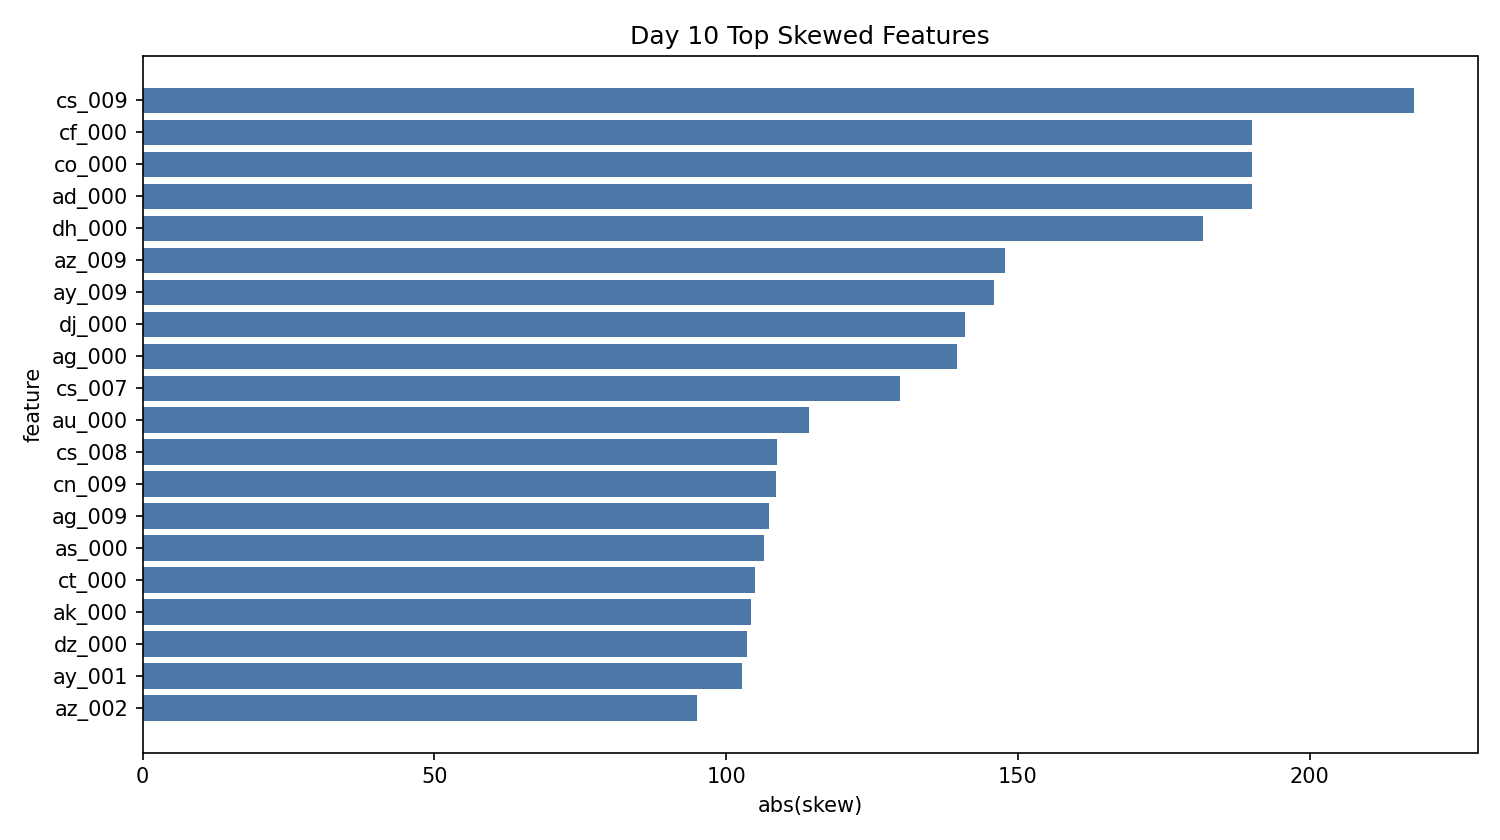

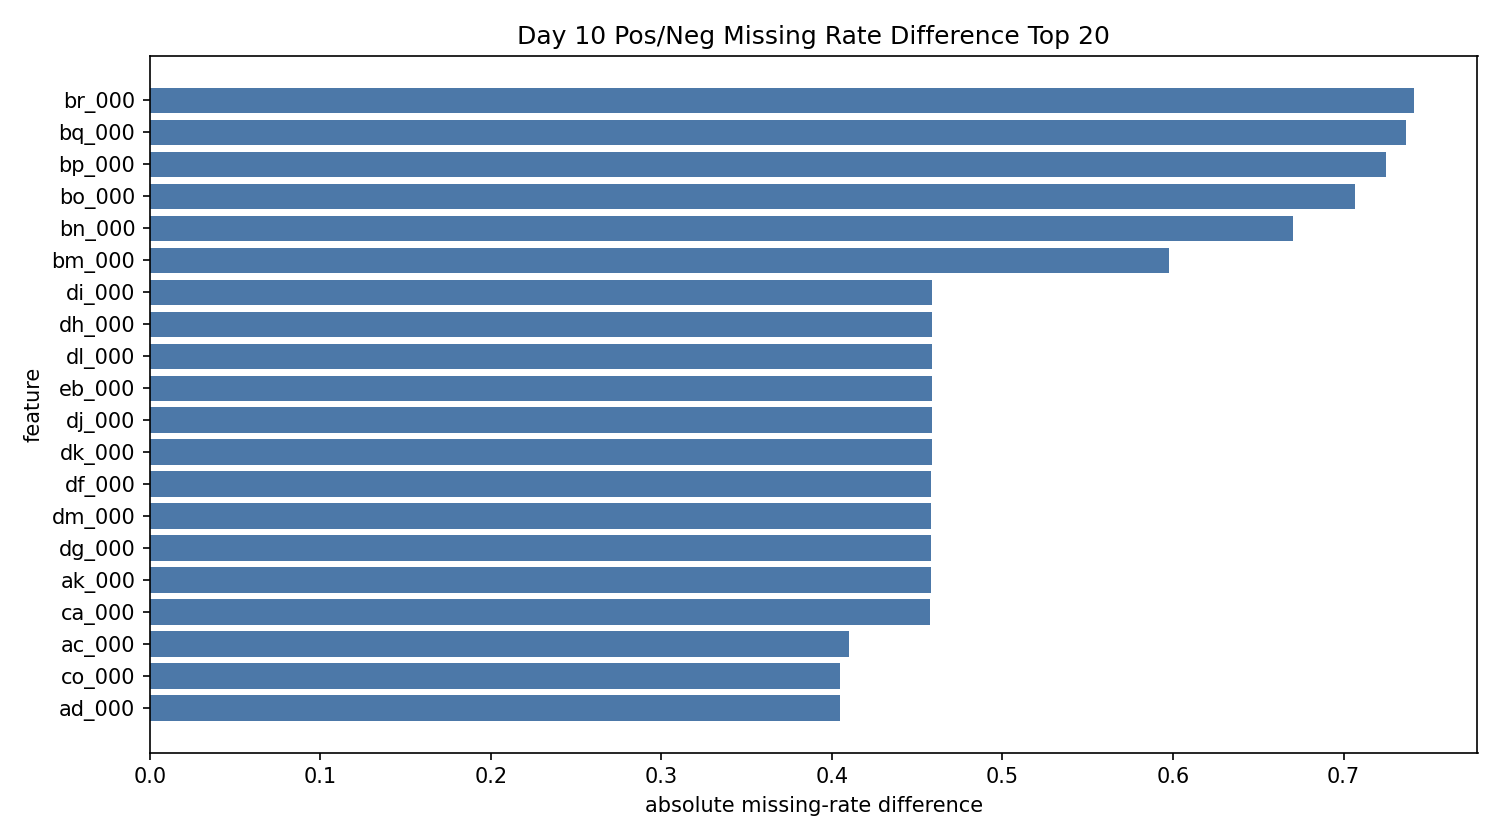

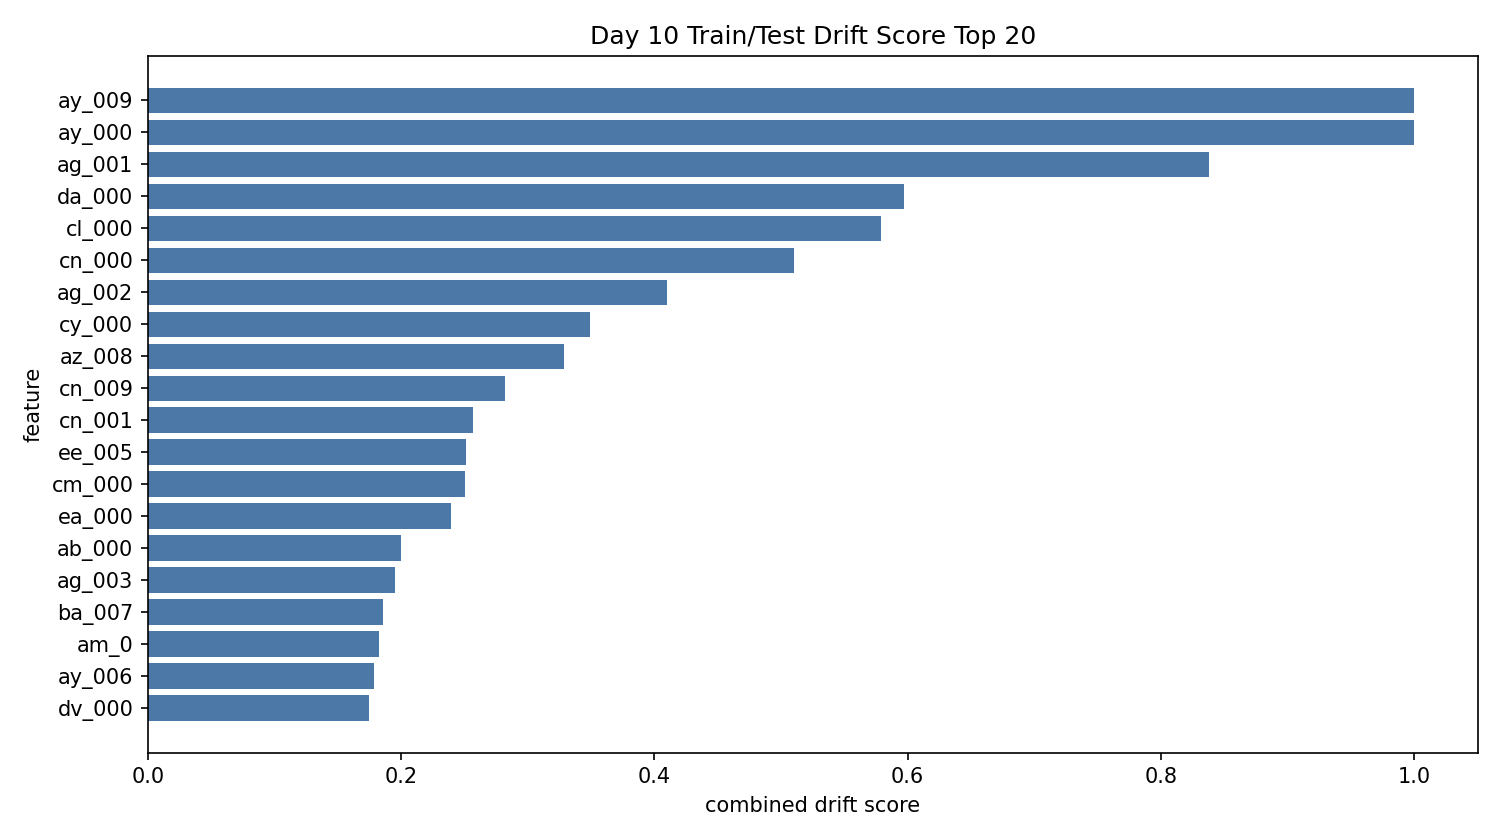

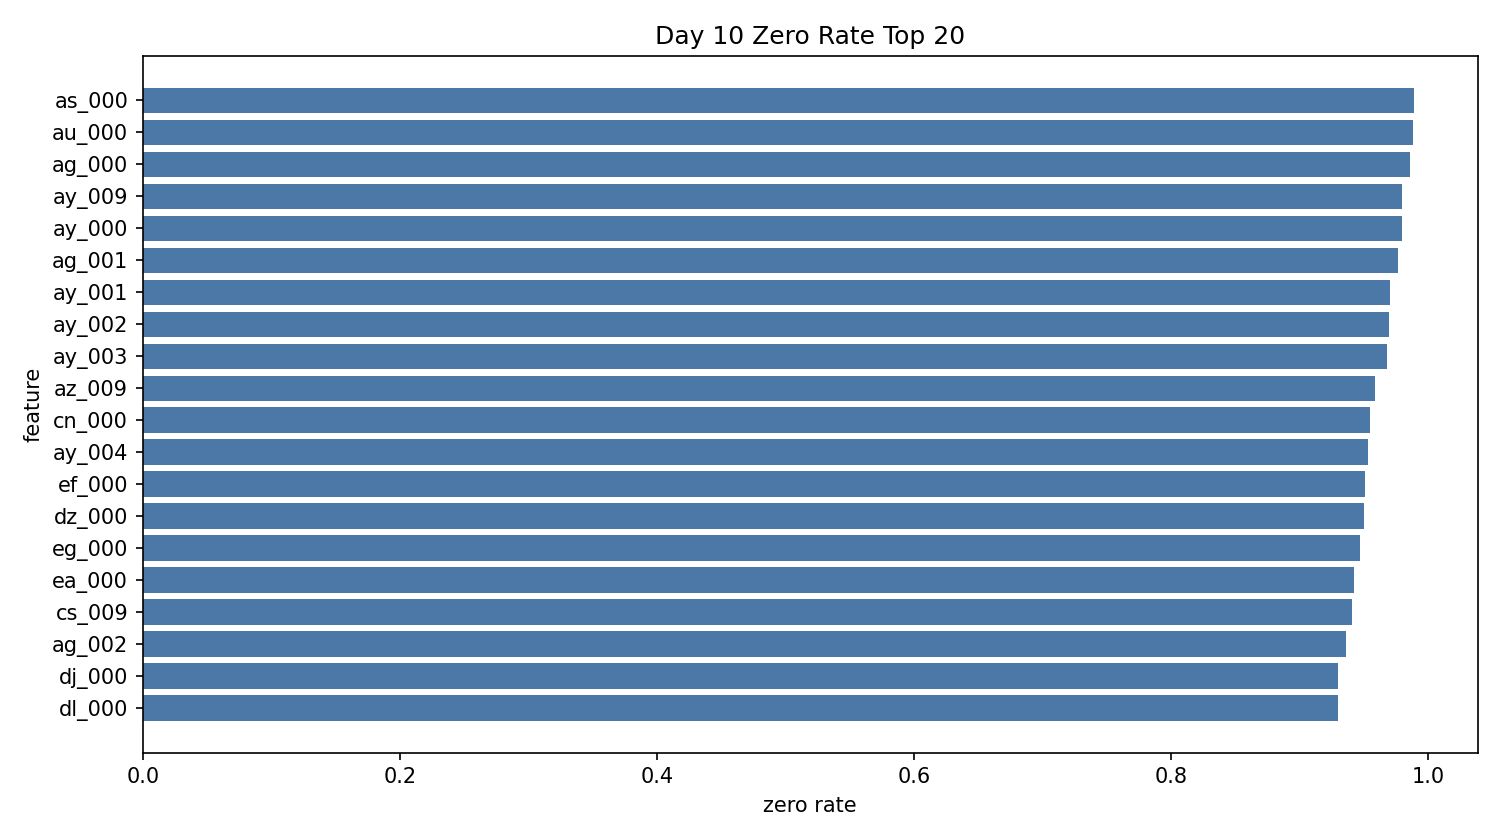

In [9]:
from IPython.display import Image, display

for figure_name in [
    "day10_top_skewed_features.png",
    "day10_pos_neg_missing_diff_top20.png",
    "day10_train_test_drift_top20.png",
    "day10_zero_rate_top20.png",
]:
    path = cfg.figures_dir / figure_name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"图表尚未生成：{path}")

## 10. 中文结论

- 高缺失字段集中在 `br_000`、`bq_000`、`bp_000`、`bo_000`、`ab_000`、`cr_000`、`bn_000`、`bm_000` 等字段，说明 Scania APS 存在明显结构性缺失。
- 高零值字段集中在 `as_000`、`au_000`、`ag_000`、`ay_009`、`ay_000`、`ag_001`、`ay_001` 等字段，说明后续可以考虑样本级 zero-count / zero-rate 等结构特征。
- 多个字段偏态极高、长尾明显，例如 `cs_009`、`cf_000`、`co_000`、`ad_000`、`dh_000`，这支持使用中位数填充和树模型，同时提醒线性模型需要缩放或稳健处理。
- pos/neg 缺失率差异最大的字段包括 `br_000`、`bq_000`、`bp_000`、`bo_000`、`bn_000`，与前面缺失模式有预测信号的结论一致。
- pos/neg 数值分布差异明显的字段包括 `ah_000`、`bg_000`、`ci_000`、`bu_000`、`cq_000`、`bv_000`、`bb_000`、`an_000`，但由于字段匿名，不能解释成具体传感器含义。
- train/test 缺失率差异整体不大，最大缺失率差异约为 0.5 个百分点；但部分字段的 p99 差异较大，说明长尾字段存在一定泛化风险。

这些现象支持 Day 11 / Day 12 做结构特征设计，例如 prefix 组统计、样本级缺失计数、零值计数、长尾截断或稳健缩放对照。但这些设计必须继续在 valid 上选择，official test 只用于最终评估。

## 11. Day 11 前缀组分析建议

Day 11 可以按匿名字段前缀，例如 `ag_*`、`ay_*`、`az_*`、`ba_*`、`cn_*` 等，分析组内缺失率、零值率、分位数和 pos/neg 差异。由于字段匿名，前缀组只能作为统计结构，不应虚构业务物理含义。